# BCS1520 - Statistics | Bootstrapping, Probability Distributions and CLT

First, we'll load the necessary Python packages. Similar to the approach in your previous labs, we'll separate the imports into logical groups:

- Standard Python packages 
- Contributed packages
- Any custom packages for the project

In [2]:
import os
import random
import math

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# Set the default style for our plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Ensure plots appear inline in the notebook
%matplotlib inline


## Part 1: Understanding Sampling and Uncertainty

In data science, we often work with samples instead of entire populations. But how accurate are our sample estimates? How much uncertainty should we attach to our conclusions? These are critical questions we'll explore in this lab.

### 1.1 Introduction to Sampling

Imagine we have a dataset representing the heights (in cm) of all university students. In reality, measuring every student would be impractical, so we typically work with samples.

Let's create a simulated population first:

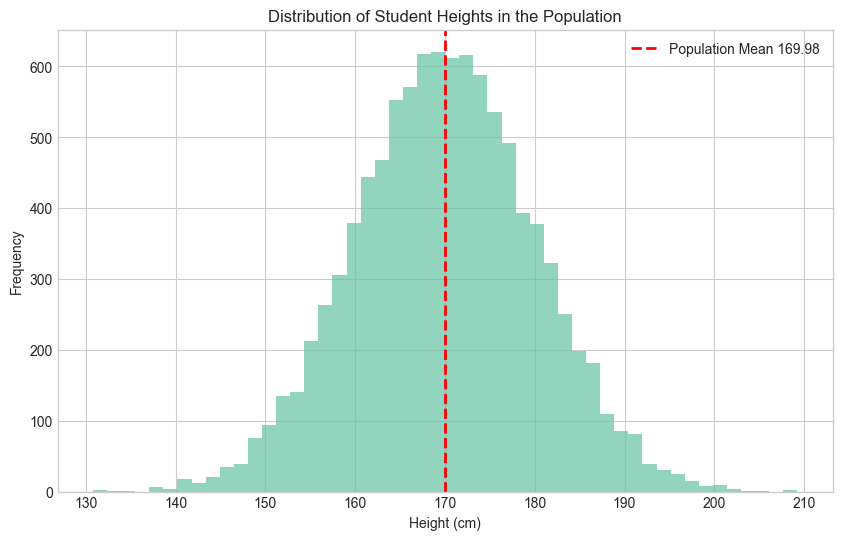

Population Mean: 169.98 cm
Population Standard Deviation: 10.03 cm


In [28]:
# Set a random seed for reproducibility
np.random.seed(42)

# Create a simulated population of 10,000 student heights
# We'll use a normal distribution with mean 170 cm and standard deviation 10 cm
population_heights = np.random.normal(170, 10, size=10000)

# Let's visualize the population distribution
plt.figure(figsize=(10, 6))
plt.hist(population_heights, bins=50, alpha=0.7)
line = plt.axvline(np.mean(population_heights), color='red', linestyle='--', linewidth=2)
plt.title('Distribution of Student Heights in the Population')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.legend([line], [f'Population Mean {np.mean(population_heights):.2f}'], loc='upper right')
plt.grid(True)
plt.show()

print(f"Population Mean: {np.mean(population_heights):.2f} cm")
print(f"Population Standard Deviation: {np.std(population_heights):.2f} cm")

Now, let's take a sample from this population and calculate the sample mean:


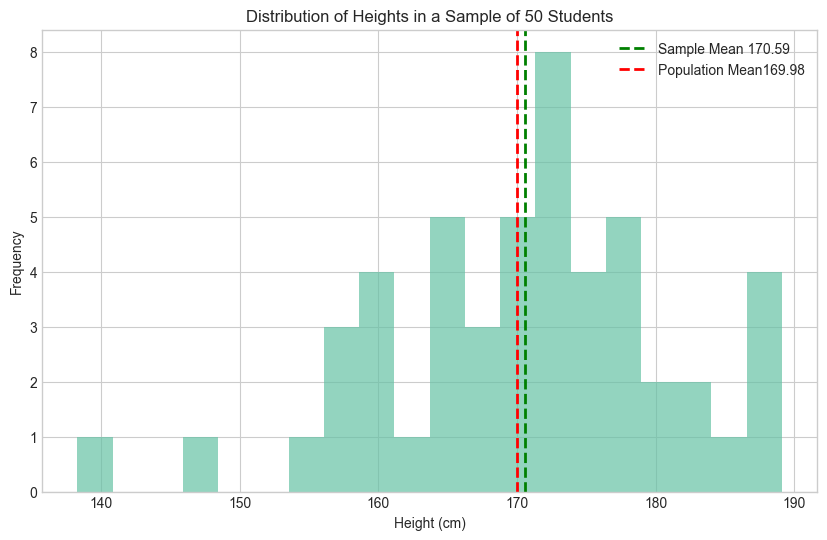

Sample Mean: 170.59 cm
Sample Standard Deviation: 10.46 cm


In [29]:
# Take a random sample of 50 students
sample_size = 50
sample_heights = np.random.choice(population_heights, size=sample_size, replace=False)

# Calculate and display the sample mean
plt.figure(figsize=(10, 6))
plt.hist(sample_heights, bins=20, alpha=0.7)
sample_line = plt.axvline(np.mean(sample_heights), color='green', linestyle='--', linewidth=2)
population_line = plt.axvline(np.mean(population_heights), color='red', linestyle='--', linewidth=2)
plt.title('Distribution of Heights in a Sample of 50 Students')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.legend([sample_line, population_line], 
           [f'Sample Mean {np.mean(sample_heights):.2f}', f'Population Mean{np.mean(population_heights):.2f}'], loc='upper right')
plt.grid(True)
plt.show()

print(f"Sample Mean: {np.mean(sample_heights):.2f} cm")
print(f"Sample Standard Deviation: {np.std(sample_heights):.2f} cm")


Notice that the sample mean is close to, but not exactly the same as, the population mean. This is sampling variability. If we took a different sample, we would get a different sample mean.

Let's take multiple samples and see how the sample means vary:


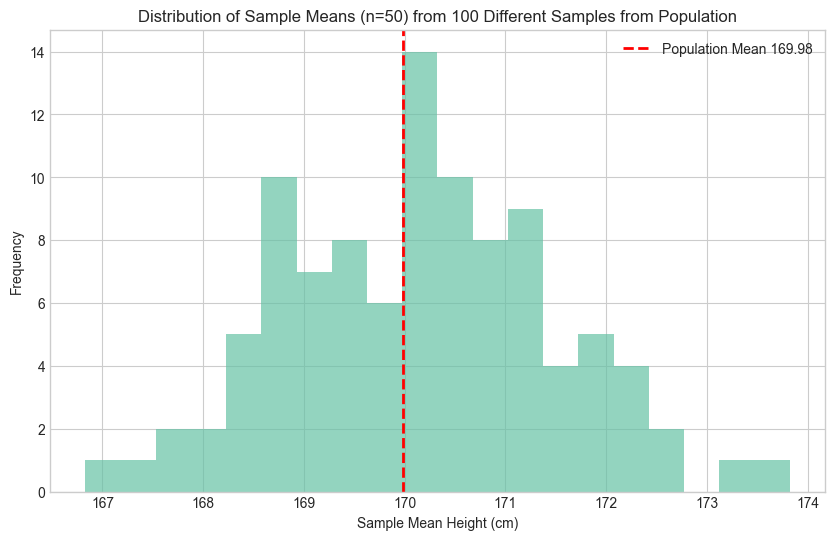

Mean of sample means: 170.14 cm
Standard deviation of sample means: 1.33 cm
Theoretical standard error (σ/√n): 1.42 cm


In [30]:
# Take 100 different samples of size 50 and calculate their means
num_samples = 100
sample_means = []

for i in range(num_samples):
    sample = np.random.choice(population_heights, size=sample_size, replace=False)
    sample_means.append(np.mean(sample))

# Plot the distribution of sample means
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=20, alpha=0.7)
line = plt.axvline(np.mean(population_heights), color='red', linestyle='--', linewidth=2)
plt.title('Distribution of Sample Means (n=50) from 100 Different Samples from Population')
plt.xlabel('Sample Mean Height (cm)')
plt.ylabel('Frequency')
plt.legend([line], [f'Population Mean {np.mean(population_heights):.2f}'], loc='upper right')
plt.grid(True)
plt.show()

print(f"Mean of sample means: {np.mean(sample_means):.2f} cm")
print(f"Standard deviation of sample means: {np.std(sample_means):.2f} cm")
print(f"Theoretical standard error (σ/√n): {np.std(population_heights)/np.sqrt(sample_size):.2f} cm")

### 1.2 Introduction to Bootstrapping

Bootstrapping is a resampling technique that helps us estimate the sampling distribution and uncertainty of a statistic (like the mean) without needing to take multiple samples from the population.

The key idea: **We treat our sample as if it were the entire population, and then resample from it (with replacement).**

Let's apply bootstrapping to estimate the uncertainty in our sample mean:

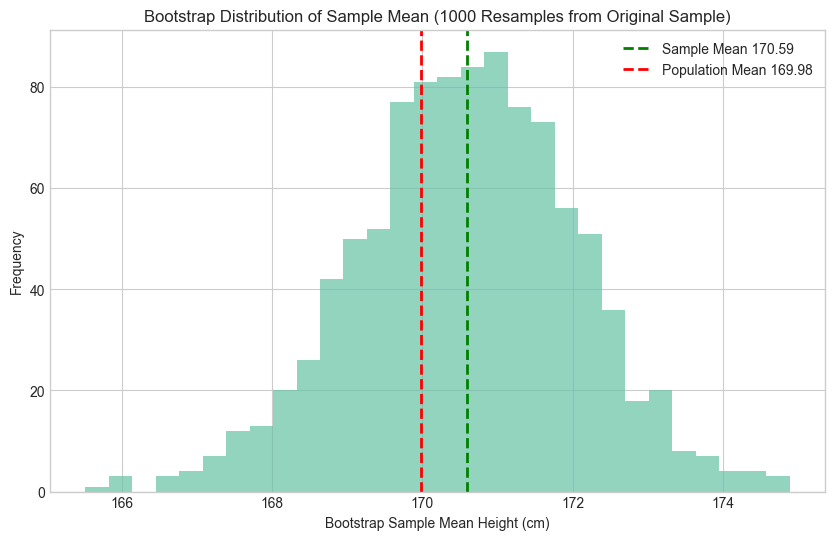

Bootstrap mean: 170.59 cm
Bootstrap standard error: 1.46 cm
95% Bootstrap Confidence Interval: (167.60, 173.44) cm


In [31]:
# Function to perform bootstrap resampling
def bootstrap_mean(data, num_bootstrap_samples=1000):
    bootstrap_means = []
    for i in range(num_bootstrap_samples):
        # Resample with replacement
        bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.mean(bootstrap_sample))
    return bootstrap_means

# Perform bootstrap resampling on our sample of 50 heights
num_bootstrap_samples = 1000
bootstrap_means = bootstrap_mean(sample_heights, num_bootstrap_samples)

# Plot the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_means, bins=30, alpha=0.7)
sample_line = plt.axvline(np.mean(sample_heights), color='green', linestyle='--', linewidth=2)
population_line = plt.axvline(np.mean(population_heights), color='red', linestyle='--', linewidth=2)
plt.title('Bootstrap Distribution of Sample Mean (1000 Resamples from Original Sample)')
plt.xlabel('Bootstrap Sample Mean Height (cm)')
plt.ylabel('Frequency')
plt.legend([sample_line, population_line],
           [f'Sample Mean {np.mean(sample_heights):.2f}', f'Population Mean {np.mean(population_heights):.2f}'], loc='upper right')
plt.show()

# Calculate 95% confidence interval from bootstrap distribution
bootstrap_ci_lower = np.percentile(bootstrap_means, 2.5)
bootstrap_ci_upper = np.percentile(bootstrap_means, 97.5)

print(f"Bootstrap mean: {np.mean(bootstrap_means):.2f} cm")
print(f"Bootstrap standard error: {np.std(bootstrap_means):.2f} cm")
print(f"95% Bootstrap Confidence Interval: ({bootstrap_ci_lower:.2f}, {bootstrap_ci_upper:.2f}) cm")

The bootstrap distribution approximates the sampling distribution of the sample mean. The standard deviation of this distribution (called the bootstrap standard error) tells us how much we expect sample means to vary from sample to sample.

The 95% confidence interval tells us that if we were to take many different samples and construct confidence intervals in this way, about 95% of those intervals would contain the true population mean.

### 1.3 Exercises

Now it's your turn to apply these concepts to a different dataset.

1. Create a simulated population of 5000 student exam scores with a mean of 75 and a standard deviation of 15.


In [35]:
# Your code here to create and visualize a population of exam scores
population_exam_scores = np.random.normal(75, 15, size=5000)


2. Take a random sample of 40 exam scores and calculate the sample mean and standard deviation.


In [36]:
# Your code here to sample from the exam scores and calculate statistics
sample_size = 40
sample_exam_scores = np.random.choice(population_exam_scores, size=sample_size, replace=False)

mean = np.mean(sample_exam_scores)
std_dev = np.std(sample_exam_scores)

3. Estimate the uncertainty in your sample mean using bootstrapping with 1000 resamples.


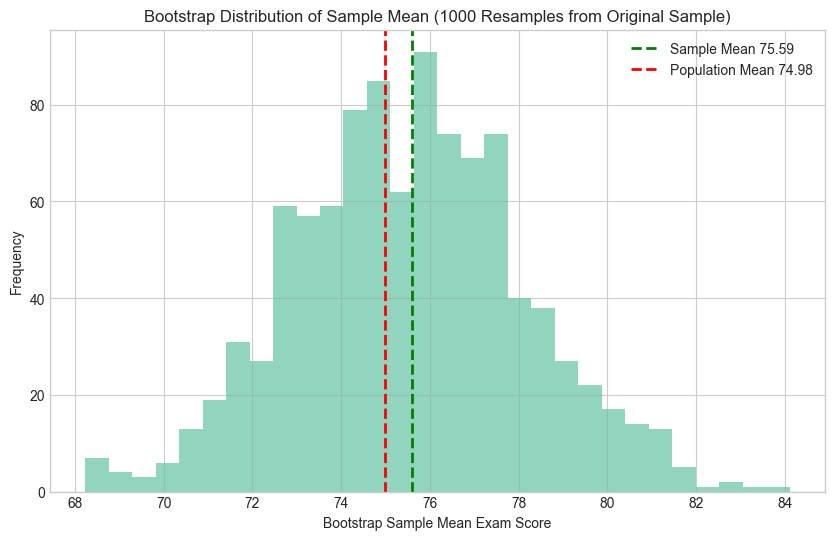

Bootstrap mean: 75.52
Bootstrap standard error: 2.60
95% Bootstrap Confidence Interval: (70.68, 80.75)


In [40]:
# Your code here to perform bootstrapping on your sample
# Perform bootstrap resampling on our sample of 50 heights
num_bootstrap_samples = 1000
bootstrap_means = bootstrap_mean(sample_exam_scores, num_bootstrap_samples)

# Plot the bootstrap distribution
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_means, bins=30, alpha=0.7)
sample_line = plt.axvline(np.mean(sample_exam_scores), color='green', linestyle='--', linewidth=2)
population_line = plt.axvline(np.mean(population_exam_scores), color='red', linestyle='--', linewidth=2)
plt.title('Bootstrap Distribution of Sample Mean (1000 Resamples from Original Sample)')
plt.xlabel('Bootstrap Sample Mean Exam Score')
plt.ylabel('Frequency')
plt.legend([sample_line, population_line],
           [f'Sample Mean {np.mean(sample_exam_scores):.2f}', f'Population Mean {np.mean(population_exam_scores):.2f}'], loc='upper right')
plt.show()

# Calculate 95% confidence interval from bootstrap distribution
bootstrap_ci_lower = np.percentile(bootstrap_means, 2.5)
bootstrap_ci_upper = np.percentile(bootstrap_means, 97.5)

print(f"Bootstrap mean: {np.mean(bootstrap_means):.2f}")
print(f"Bootstrap standard error: {np.std(bootstrap_means):.2f}")
print(f"95% Bootstrap Confidence Interval: ({bootstrap_ci_lower:.2f}, {bootstrap_ci_upper:.2f})")

4. How does the bootstrap standard error compare with the theoretical standard error (σ/√n)?


In [39]:
# Your code to compare the bootstrap standard error with the theoretical standard error
print(f"Theoretical standard error (σ/√n): {np.std(population_exam_scores)/np.sqrt(sample_size):.2f}")

Theoretical standard error (σ/√n): 2.34


## Part 2: Probability Distributions and Empirical Data

In data science, we often encounter data that follows certain probability distributions. Understanding these distributions helps us model data, make predictions, and quantify uncertainty.

### 2.1 Common Probability Distributions

Let's explore some common probability distributions and see how well they describe real-world data.

#### 2.1.1 The Normal Distribution

The normal distribution is a continuous probability distribution that's symmetric around its mean. Many natural phenomena follow this distribution, including heights, IQ scores, and measurement errors.

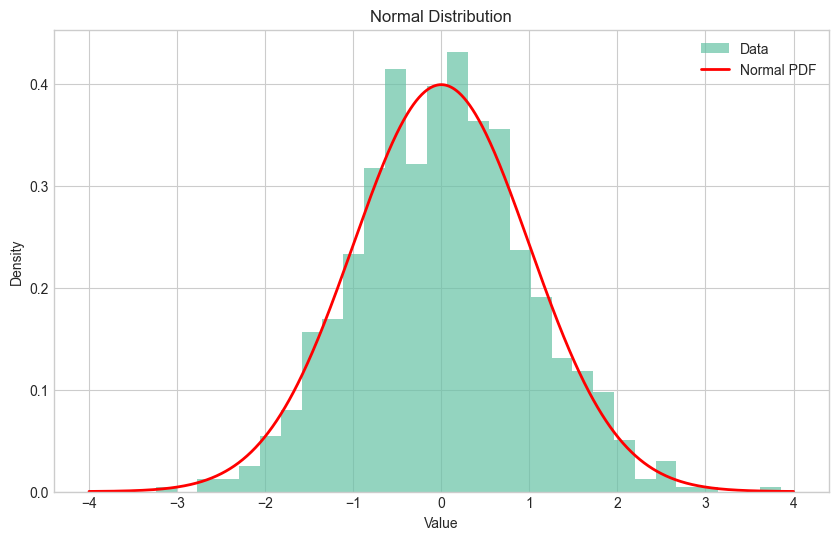

In [17]:
# Generate data from a normal distribution
np.random.seed(42)
normal_data = np.random.normal(loc=0, scale=1, size=1000)

# Plot the histogram and overlay the PDF
plt.figure(figsize=(10, 6))
plt.hist(normal_data, bins=30, density=True, alpha=0.7, label='Data')

# Generate points for the theoretical normal PDF
x = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(x, loc=0, scale=1)
plt.plot(x, pdf, 'r-', linewidth=2, label='Normal PDF')

plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

#### 2.1.2 The Binomial Distribution

The binomial distribution models a discrete quantity - the number of successes in a fixed number of independent trials, each with the same probability of success.


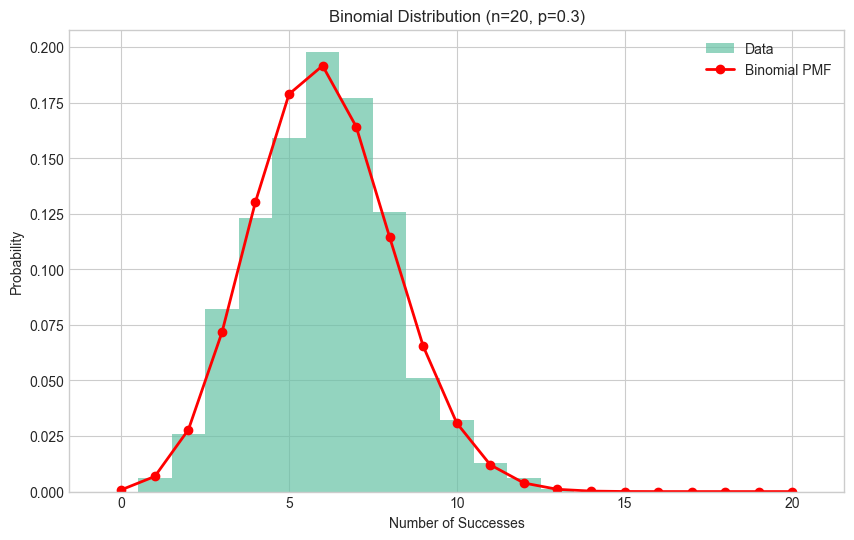

In [18]:
# Generate data from a binomial distribution
n_trials = 20  # number of trials
p_success = 0.3  # probability of success
binomial_data = np.random.binomial(n=n_trials, p=p_success, size=1000)

# Plot the histogram and overlay the PMF
plt.figure(figsize=(10, 6))
plt.hist(binomial_data, bins=range(0, n_trials+2), density=True, alpha=0.7, label='Data', align='left')

# Generate points for the theoretical binomial PMF
x = np.arange(0, n_trials+1)
pmf = stats.binom.pmf(x, n=n_trials, p=p_success)
plt.plot(x, pmf, 'ro-', linewidth=2, label='Binomial PMF')

plt.title(f'Binomial Distribution (n={n_trials}, p={p_success})')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.legend()
plt.show()


#### 2.1.3 The Poisson Distribution

The Poisson distribution models a discrete quantity - the number of events occurring in a fixed interval of time or space when these events happen at a constant average rate independently of the time since the last event.

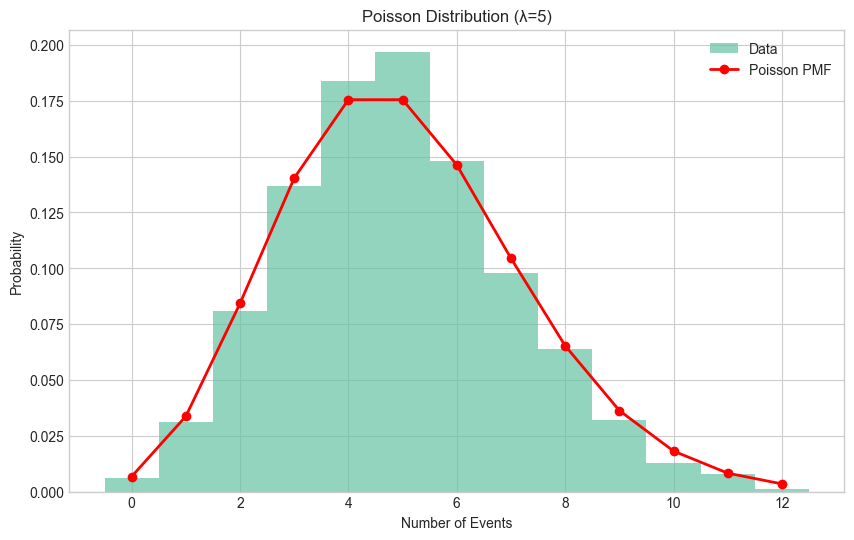

In [19]:
# Generate data from a Poisson distribution
lambda_param = 5  # average rate
poisson_data = np.random.poisson(lam=lambda_param, size=1000)

# Plot the histogram and overlay the PMF
plt.figure(figsize=(10, 6))
plt.hist(poisson_data, bins=range(0, max(poisson_data)+2), density=True, alpha=0.7, label='Data', align='left')

# Generate points for the theoretical Poisson PMF
x = np.arange(0, max(poisson_data)+1)
pmf = stats.poisson.pmf(x, mu=lambda_param)
plt.plot(x, pmf, 'ro-', linewidth=2, label='Poisson PMF')

plt.title(f'Poisson Distribution (λ={lambda_param})')
plt.xlabel('Number of Events')
plt.ylabel('Probability')
plt.legend()
plt.show()

### 2.2 Fitting Distributions to Empirical Data

When working with real data, we often want to find a probability distribution that best describes our data. Let's explore this with a simulated example:

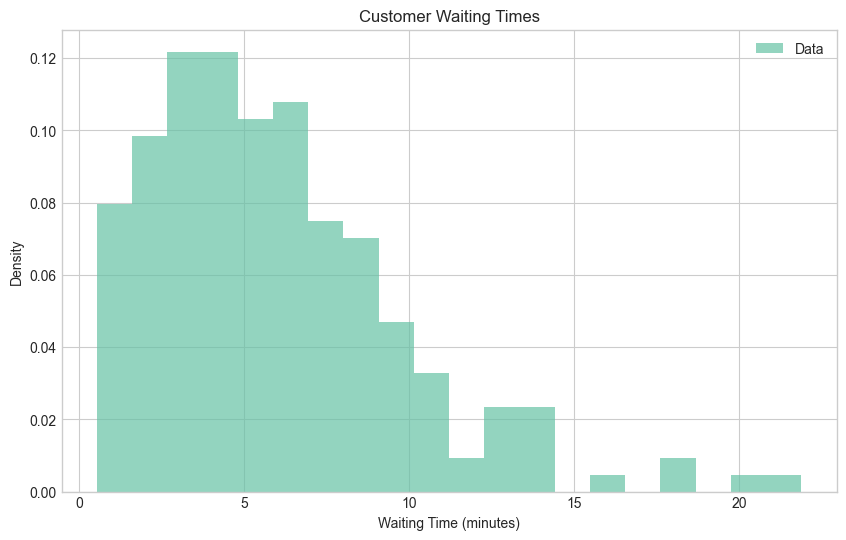

Mean Waiting Time: 5.96 minutes
Standard Deviation: 3.82 minutes


In [20]:
# Load a simulated dataset of customer waiting times (in minutes)
np.random.seed(42)
waiting_times = np.random.gamma(shape=2, scale=3, size=200)

# Plot the histogram of waiting times
plt.figure(figsize=(10, 6))
plt.hist(waiting_times, bins=20, density=True, alpha=0.7, label='Data')
plt.title('Customer Waiting Times')
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"Mean Waiting Time: {np.mean(waiting_times):.2f} minutes")
print(f"Standard Deviation: {np.std(waiting_times):.2f} minutes")

Looking at the histogram, the waiting times appear to be right-skewed, which is common for time measurements like this. Let's try fitting different distributions and see which one fits best.


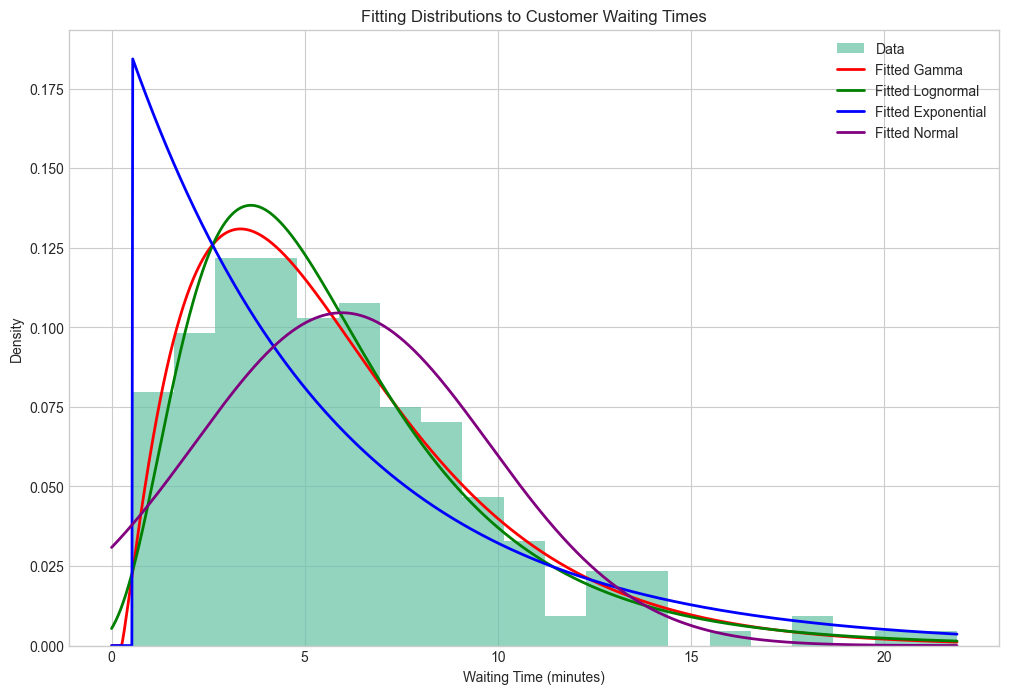

In [21]:
# Fit different distributions to the data
distributions = [
    stats.gamma,
    stats.lognorm,
    stats.expon,
    stats.norm
]

dist_names = ['Gamma', 'Lognormal', 'Exponential', 'Normal']
colors = ['red', 'green', 'blue', 'purple']

plt.figure(figsize=(12, 8))
plt.hist(waiting_times, bins=20, density=True, alpha=0.7, label='Data')

for i, dist in enumerate(distributions):
    # Fit the distribution to the data
    params = dist.fit(waiting_times)
    
    # Generate points for the fitted PDF
    x = np.linspace(0, max(waiting_times), 1000)
    pdf = dist.pdf(x, *params)
    
    plt.plot(x, pdf, color=colors[i], linewidth=2, label=f'Fitted {dist_names[i]}')
    
plt.title('Fitting Distributions to Customer Waiting Times')
plt.xlabel('Waiting Time (minutes)')
plt.ylabel('Density')
plt.legend()
plt.show()

In this case, since the data was generated from a gamma distribution, we expect the gamma distribution to provide the best fit.


### 2.3 Exercises

Now it's your turn to apply these concepts to a different dataset.

1. Generate a dataset of 300 simulated reaction times (in milliseconds) that follows a lognormal distribution with mean parameter 5.5 and standard deviation parameter 0.4.


In [41]:
# Your code here to generate and visualize simulated reaction times
reaction_times = np.random.lognormal(mean=5.5, sigma=0.4, size=300)

2. Fit the following distributions to your reaction time data: normal, lognormal, gamma, and exponential. Which distribution fits best?

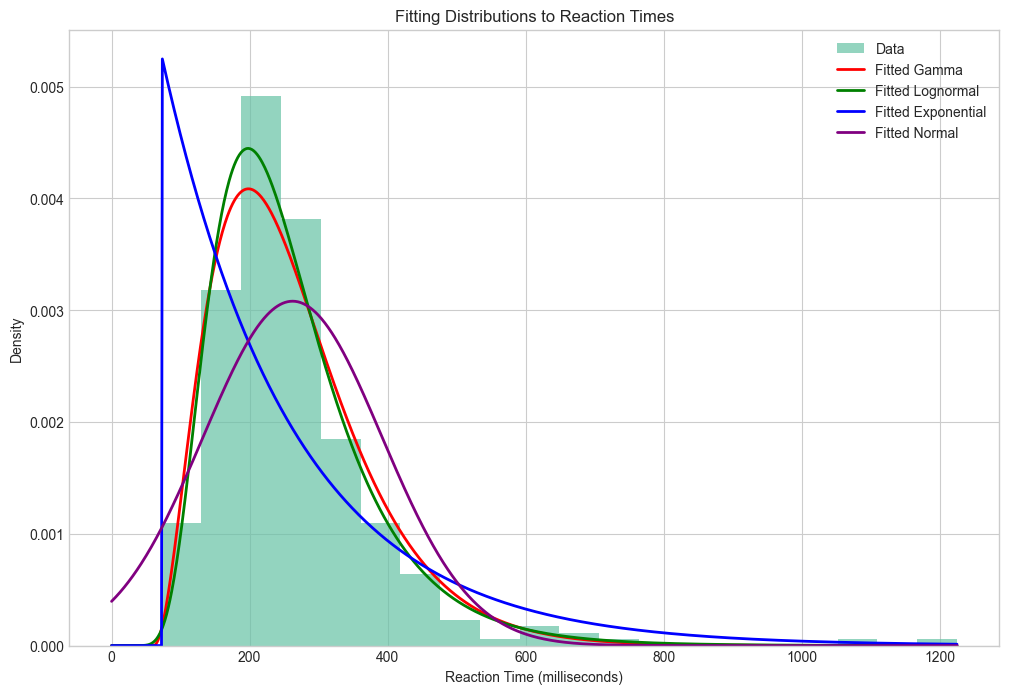

In [43]:
# your code here to fit several distributions
# Fit different distributions to the data
distributions = [
    stats.gamma,
    stats.lognorm,
    stats.expon,
    stats.norm
]

dist_names = ['Gamma', 'Lognormal', 'Exponential', 'Normal']
colors = ['red', 'green', 'blue', 'purple']

plt.figure(figsize=(12, 8))
plt.hist(reaction_times, bins=20, density=True, alpha=0.7, label='Data')

for i, dist in enumerate(distributions):
    # Fit the distribution to the data
    params = dist.fit(reaction_times)
    
    # Generate points for the fitted PDF
    x = np.linspace(0, max(reaction_times), 1000)
    pdf = dist.pdf(x, *params)
    
    plt.plot(x, pdf, color=colors[i], linewidth=2, label=f'Fitted {dist_names[i]}')
    
plt.title('Fitting Distributions to Reaction Times')
plt.xlabel('Reaction Time (milliseconds)')
plt.ylabel('Density')
plt.legend()
plt.show()

## Part 3: The Central Limit Theorem

The Central Limit Theorem (CLT) is one of the most fundamental concepts in statistics. It states that when we take a large number of random samples from a population, the distribution of sample means will be approximately normal, regardless of the shape of the original population distribution.

This is incredibly powerful because it allows us to make inferences about populations using the normal distribution, even when the population isn't normally distributed.

### 3.1 Demonstrating the Central Limit Theorem

Let's demonstrate the CLT using a non-normal population: a uniform distribution.



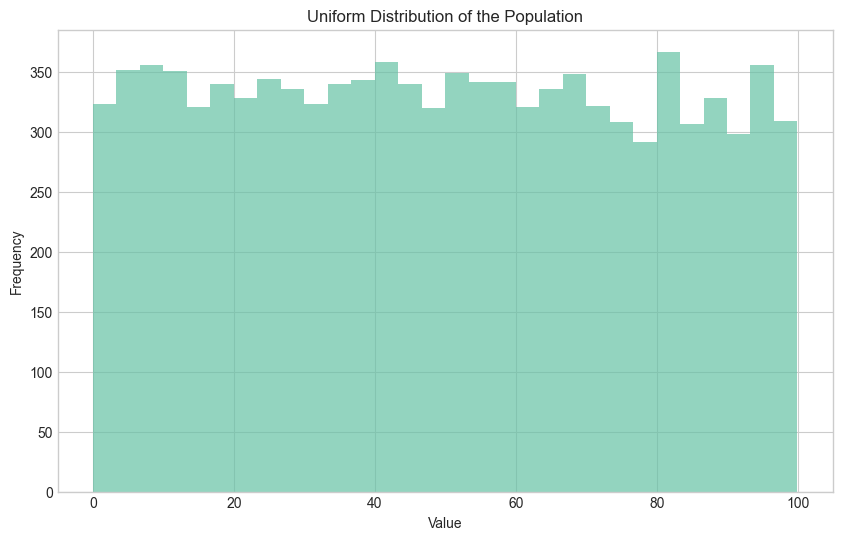

Population Mean: 49.42
Population Standard Deviation: 28.76


In [22]:
# Create a population with a uniform distribution
np.random.seed(42)
uniform_population = np.random.uniform(0, 100, size=10000)

# Visualize the population
plt.figure(figsize=(10, 6))
plt.hist(uniform_population, bins=30, alpha=0.7)
plt.title('Uniform Distribution of the Population')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

print(f"Population Mean: {np.mean(uniform_population):.2f}")
print(f"Population Standard Deviation: {np.std(uniform_population):.2f}")

Now, let's take many random samples from this population and calculate their means:


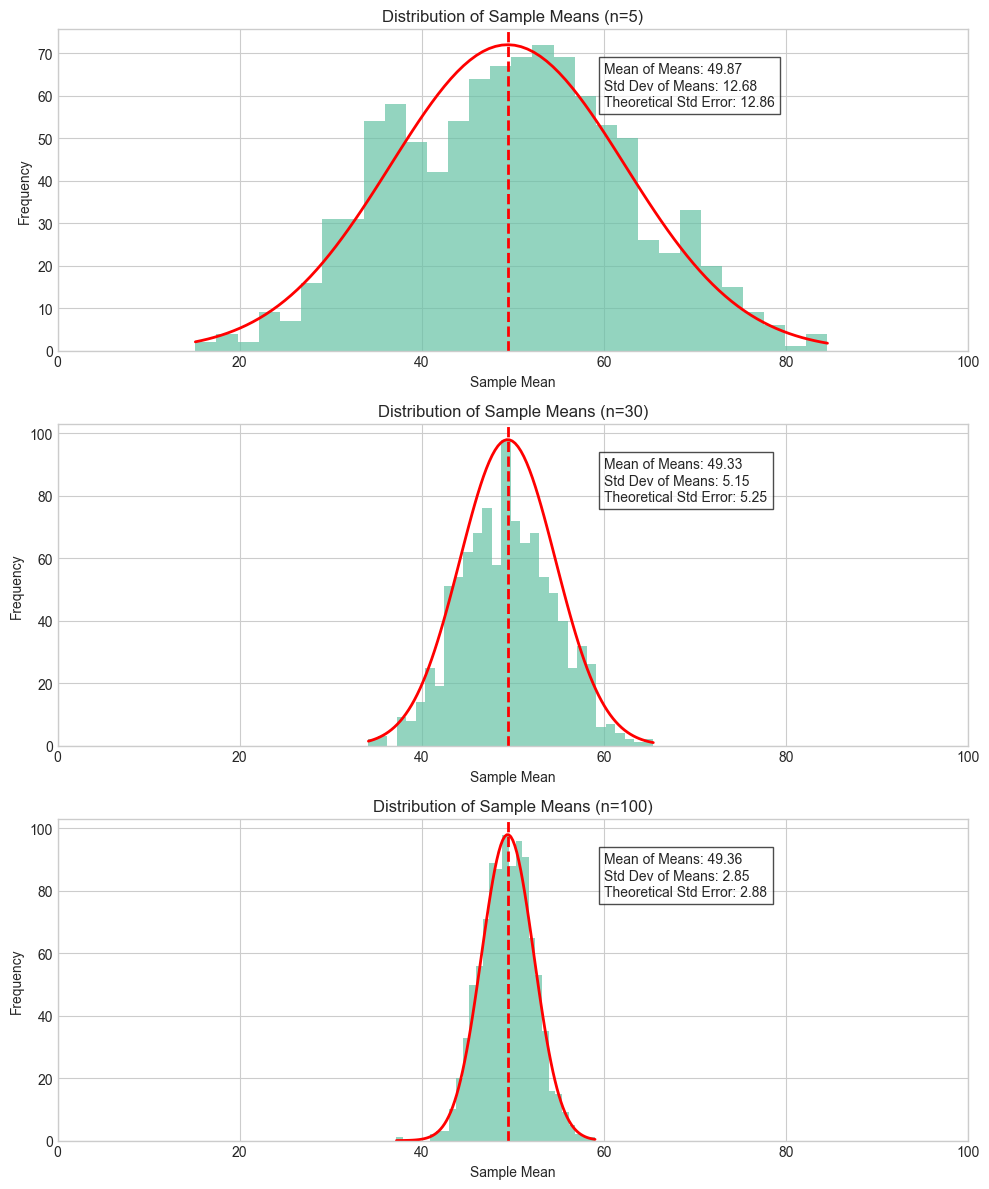

In [24]:
# Take many samples and calculate their means
sample_sizes = [5, 30, 100]
num_samples = 1000

fig, axes = plt.subplots(len(sample_sizes), 1, figsize=(10, 12))

for i, sample_size in enumerate(sample_sizes):
    sample_means = []
    
    for _ in range(num_samples):
        sample = np.random.choice(uniform_population, size=sample_size, replace=False)
        sample_means.append(np.mean(sample))
    
    # Plot the distribution of sample means
    axes[i].hist(sample_means, bins=30, alpha=0.7)
    axes[i].axvline(np.mean(uniform_population), color='red', linestyle='--', linewidth=2)
    
    # Overlay the normal distribution
    x = np.linspace(min(sample_means), max(sample_means), 100)
    theoretical_mean = np.mean(uniform_population)
    theoretical_std = np.std(uniform_population) / np.sqrt(sample_size)
    normal_pdf = stats.norm.pdf(x, theoretical_mean, theoretical_std)
    
    # Scale the PDF to match the histogram height
    hist_heights, _ = np.histogram(sample_means, bins=30)
    scaling_factor = max(hist_heights) / max(normal_pdf)
    
    axes[i].plot(x, normal_pdf * scaling_factor, 'r-', linewidth=2)
    
    axes[i].set_title(f'Distribution of Sample Means (n={sample_size})')
    axes[i].set_xlabel('Sample Mean')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlim(0, 100)
    # Add text with statistics
    axes[i].text(60, max(hist_heights)*0.8, 
                f'Mean of Means: {np.mean(sample_means):.2f}\nStd Dev of Means: {np.std(sample_means):.2f}\nTheoretical Std Error: {theoretical_std:.2f}', 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

Notice how the distribution of sample means becomes more normal as the sample size increases, demonstrating the Central Limit Theorem. Also, the standard deviation of sample means (standard error) decreases as sample size increases, showing that larger samples give more precise estimates.

### 3.2 The Central Limit Theorem in Action

To further illustrate the power of the CLT, let's apply it to a real-world example. Imagine we're analyzing the daily revenue of a coffee shop, which has a right-skewed distribution:


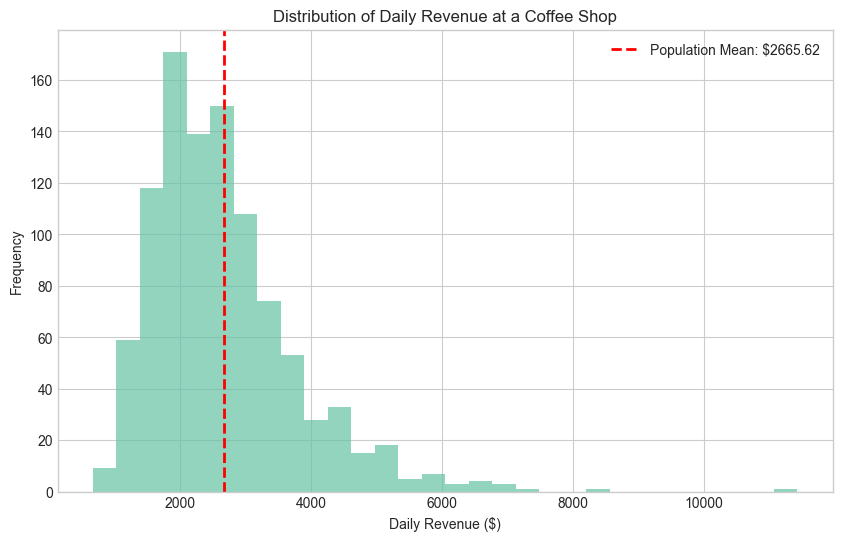

Mean Daily Revenue: $2665.62
Median Daily Revenue: $2471.81
Standard Deviation: $1115.97


In [ ]:
# Simulate daily revenue data with a right-skewed distribution (lognormal)
np.random.seed(42)
daily_revenue = np.random.lognormal(mean=5.5, sigma=0.4, size=1000)

# Convert to more realistic values (in dollars)
daily_revenue = daily_revenue * 10

# Visualize the daily revenue
plt.figure(figsize=(10, 6))
plt.hist(daily_revenue, bins=30, alpha=0.7)
plt.title('Distribution of Daily Revenue at a Coffee Shop')
plt.xlabel('Daily Revenue ($)')
plt.ylabel('Frequency')
line = plt.axvline(np.mean(daily_revenue), color='red', linestyle='--', linewidth=2)
plt.legend([line], [f'Population Mean: ${np.mean(daily_revenue):.2f}'], loc='upper right')
plt.grid(True)
plt.show()

print(f"Mean Daily Revenue: ${np.mean(daily_revenue):.2f}")
print(f"Median Daily Revenue: ${np.median(daily_revenue):.2f}")
print(f"Standard Deviation: ${np.std(daily_revenue):.2f}")


Now, let's imagine we're interested in the weekly average revenue. According to the CLT, the distribution of weekly average revenues should be approximately normal:


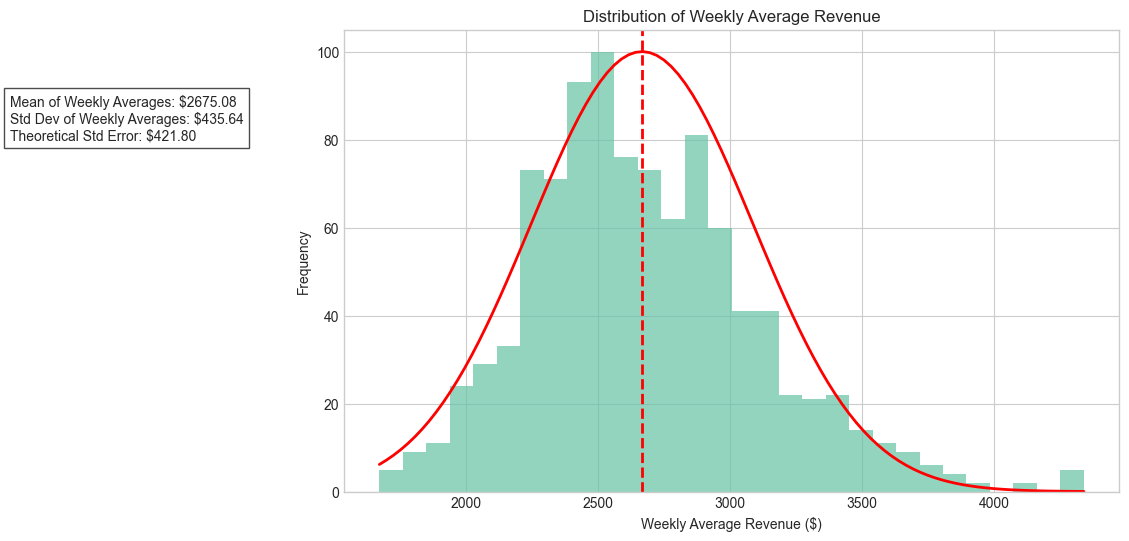

In [32]:
# Simulate weekly average revenues (samples of size 7)
num_weeks = 1000
weekly_averages = []

for _ in range(num_weeks):
    week_sample = np.random.choice(daily_revenue, size=7, replace=False)
    weekly_averages.append(np.mean(week_sample))

# Visualize the distribution of weekly average revenues
plt.figure(figsize=(10, 6))
plt.hist(weekly_averages, bins=30, alpha=0.7)
plt.title('Distribution of Weekly Average Revenue')
plt.xlabel('Weekly Average Revenue ($)')
plt.ylabel('Frequency')
plt.axvline(np.mean(daily_revenue), color='red', linestyle='--', linewidth=2)

# Overlay the normal distribution
x = np.linspace(min(weekly_averages), max(weekly_averages), 100)
theoretical_mean = np.mean(daily_revenue)
theoretical_std = np.std(daily_revenue) / np.sqrt(7)  # standard error for sample size 7
normal_pdf = stats.norm.pdf(x, theoretical_mean, theoretical_std)

# Scale the PDF to match the histogram height
hist_heights, _ = np.histogram(weekly_averages, bins=30)
scaling_factor = max(hist_heights) / max(normal_pdf)
plt.plot(x, normal_pdf * scaling_factor, 'r-', linewidth=2)

plt.text(270, max(hist_heights)*0.8, 
         f'Mean of Weekly Averages: ${np.mean(weekly_averages):.2f}\nStd Dev of Weekly Averages: ${np.std(weekly_averages):.2f}\nTheoretical Std Error: ${theoretical_std:.2f}', 
         fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.show()


The distribution of weekly average revenues is much closer to normal than the original daily revenue distribution. This illustrates a key benefit of the CLT: we can use the normal distribution to make inferences about means, even when the underlying data is skewed.


### 3.3 Exercises

Now it's your turn to explore the Central Limit Theorem.

1. Create a highly skewed population of 10,000 values (e.g., using a gamma distribution).


In [44]:
# Your code here to create and visualize a skewed population
skewed_population = np.random.gamma(shape=2, scale=3, size=10000)

2. Demonstrate the CLT by taking samples of sizes 5, 20, and 50, and plotting the distribution of sample means for each.


Sample Size: 5, Standard Error: 0.89
Sample Size: 20, Standard Error: 0.21
Sample Size: 50, Standard Error: 0.09


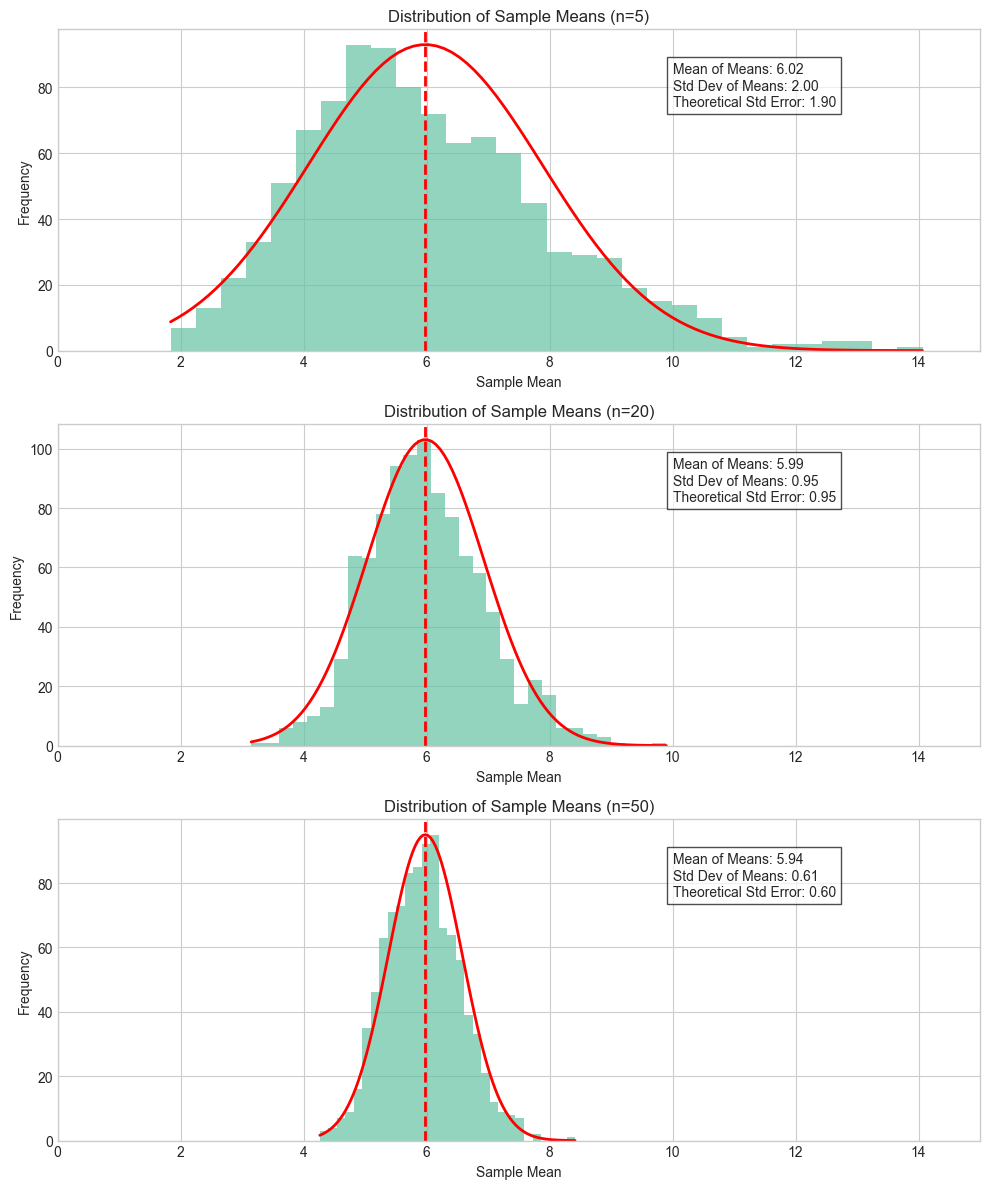

In [49]:
# Your code here to demonstrate the CLT
# Take many samples and calculate their means
sample_sizes = [5, 20, 50]
num_samples = 1000

fig, axes = plt.subplots(len(sample_sizes), 1, figsize=(10, 12))

for i, sample_size in enumerate(sample_sizes):
    sample_means = []
    
    for _ in range(num_samples):
        sample = np.random.choice(skewed_population, size=sample_size, replace=False)
        sample_means.append(np.mean(sample))
    
    # Compute standard error
    print(f"Sample Size: {sample_size}, Standard Error: {np.std(sample_means)/np.sqrt(sample_size):.2f}")

    # Plot the distribution of sample means
    axes[i].hist(sample_means, bins=30, alpha=0.7)
    axes[i].axvline(np.mean(skewed_population), color='red', linestyle='--', linewidth=2)
    
    # Overlay the normal distribution
    x = np.linspace(min(sample_means), max(sample_means), 100)
    theoretical_mean = np.mean(skewed_population)
    theoretical_std = np.std(skewed_population) / np.sqrt(sample_size)
    normal_pdf = stats.norm.pdf(x, theoretical_mean, theoretical_std)
    
    # Scale the PDF to match the histogram height
    hist_heights, _ = np.histogram(sample_means, bins=30)
    scaling_factor = max(hist_heights) / max(normal_pdf)
    
    axes[i].plot(x, normal_pdf * scaling_factor, 'r-', linewidth=2)
    
    axes[i].set_title(f'Distribution of Sample Means (n={sample_size})')
    axes[i].set_xlabel('Sample Mean')
    axes[i].set_ylabel('Frequency')
    axes[i].set_xlim(0, 15)
    # Add text with statistics
    axes[i].text(10, max(hist_heights)*0.8, 
                f'Mean of Means: {np.mean(sample_means):.2f}\nStd Dev of Means: {np.std(sample_means):.2f}\nTheoretical Std Error: {theoretical_std:.2f}', 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

3. How does the standard error change as the sample size increases? Does it match the theoretical formula σ/√n?


In [ ]:
# Your code here to analyze how standard error changes with sample size
# Check the prints in the above cell's output